In [1]:
# basic tools
import os
os.environ["OMP_NUM_THREADS"] = "1" # Specificaly for small data set to avoid memory leak

import numpy as np
import pandas as pd
import duckdb # Data base

#Visual tools
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.collections as clt
from adjustText import adjust_text
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#Analysis tools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.stats as stats
from scipy.integrate import trapezoid
import sklearn.model_selection as skm
from sklearn.ensemble import RandomForestRegressor as RFR
import shap
import joblib

In [2]:
# Connect to a database file 
con = duckdb.connect('../aav_manufacturing.db') 

# Post-Production Analysis

## Calculating derived variables from raw data

In [3]:
query = """SELECT * FROM telemetry_aligned """
df_aligned = con.execute(query).df()

# Calculate instantaneous rates in the aligned dataframe
df_aligned = df_aligned.sort_values(['Batch_ID', 'Hour'])
df_aligned['dt'] = df_aligned.groupby('Batch_ID')['Hour'].diff()

# Growth Rate (mu): (ΔVCD / VCD) / Δt
df_aligned['Growth_Rate'] = df_aligned.groupby('Batch_ID')['VCD'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Production Rate (qp): ΔP / (VCD * Δt)
df_aligned['Production_Rate'] = df_aligned.groupby('Batch_ID')['Product'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Consumption Rate (qg): ΔG / (VCD * Δt)
df_aligned['Consumption_Rate'] = df_aligned.groupby('Batch_ID')['Glucose'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Register with DuckDB
con.register('telemetry_aligned', df_aligned)

## Agregating required data for analysis

In [4]:
query = """
SELECT 
    o.Batch_ID, 
    o.Status, 
    o.Full_Titer, 
    MAX(t.Ammonia) AS Max_Ammonia,
    MAX(t.Lactate) AS Max_Lactate,
    MIN(t.pH) AS Min_pH,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Growth_Rate END) AS Avg_Growth_Rate,
    AVG(CASE WHEN t.Hour >= 72 THEN t.Production_Rate END) AS Avg_Prod_Rate,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Consumption_Rate END) AS Avg_Gluc_Cons
FROM outcomes o
JOIN telemetry_aligned t ON o.Batch_ID = t.Batch_ID
GROUP BY o.Batch_ID, o.Status, o.Full_Titer
"""

df_pca_final = con.execute(query).df()


## First PCA for relevant Principal Components

In [5]:
# Define features for the model
feature_cols = ['Max_Ammonia', 'Max_Lactate', 'Min_pH', 
                'Avg_Growth_Rate', 'Avg_Prod_Rate', 'Avg_Gluc_Cons']

# Handle missing values (if any rates couldn't be calculated)
df_pca_final = df_pca_final.dropna(subset=feature_cols)

# Scale the data (Mandatory for PCA)
scaler = StandardScaler()
X = scaler.fit_transform(df_pca_final[feature_cols])

In [6]:
# Run PCA
pca = PCA(n_components=5)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2','PC3','PC4','PC5'])
df_pca_plot['Status'] = df_pca_final['Status'].values

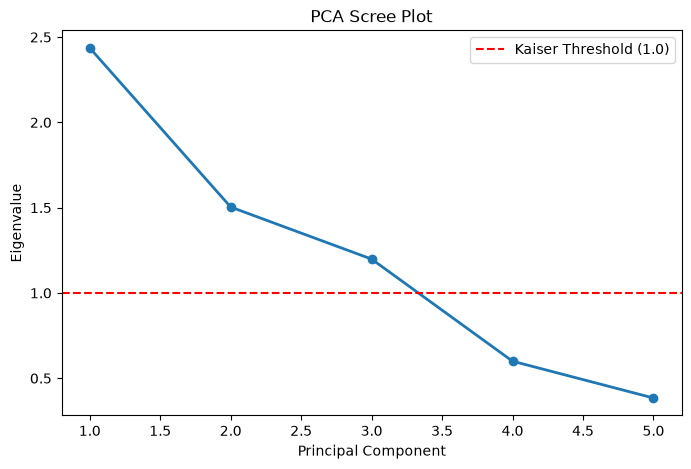

In [7]:
# Calculate Eigenvalues
eigenvalues = pca.explained_variance_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Threshold (1.0)')
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

## Second PCA for visualization and clustering analysis

In [8]:
# Run PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
df_pca_plot['Status'] = df_pca_final['Status'].values

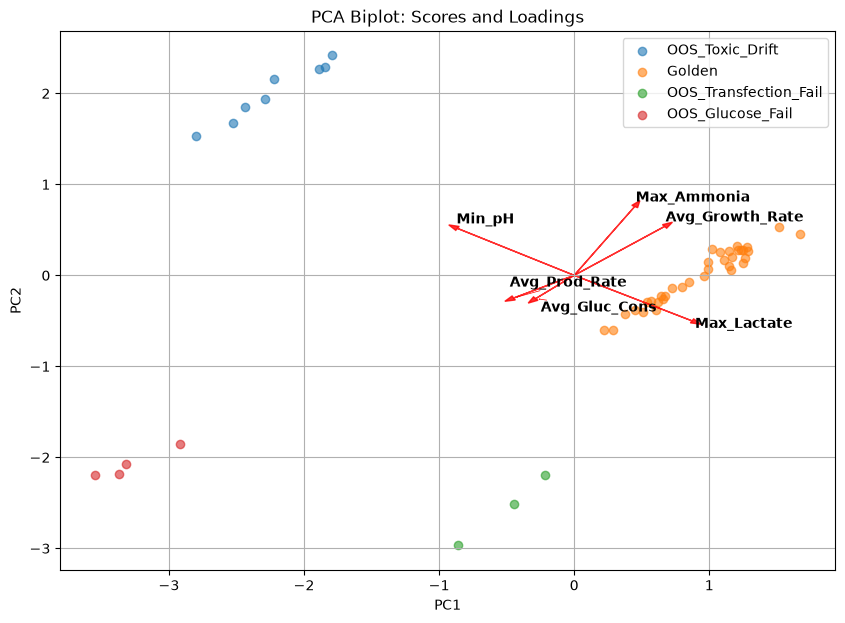

In [9]:
# Extract loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create Biplot
plt.figure(figsize=(10, 7))

# Plot the scores (the batches)
for status in df_pca_final['Status'].unique():
    mask = df_pca_final['Status'] == status
    plt.scatter(principal_components[mask, 0], principal_components[mask, 1], label=status, alpha=0.6)

texts = []
for i, feature in enumerate(feature_cols):
    texts.append(plt.text(loadings[i, 0], loadings[i, 1], feature, fontweight='bold'))
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.8, head_width=0.05)
# This function iteratively moves text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))


plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot: Scores and Loadings')
plt.legend()
plt.grid(True)
plt.show()

## Golden batch threshold

In [10]:
# 1. Fit PCA ONLY on Golden Batches to define the 'Normal' space
golden_mask = df_pca_final['Status'] == 'Golden'
p_components = 3
pca_golden = PCA(n_components=p_components)
scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_pca_final[golden_mask][feature_cols])
pca_golden.fit(train_scaled)

# 2. Project ALL batches (Golden + OOS) into this 'Golden Space'
all_scaled = scaler.transform(df_pca_final[feature_cols])
scores = pca_golden.transform(all_scaled)

eigenvalues = pca_golden.explained_variance_
t2_values = np.sum((scores**2) / eigenvalues, axis=1)

# 2. Calculate the 99% Confidence Threshold (UCL - Upper Control Limit)
# n: number of golden batches used for training
# p: number of PCs retained 
n = df_pca_final[golden_mask].shape[0]
p = p_components
alpha = 0.01
t2_threshold = (p * (n - 1) / (n - p)) * stats.f.ppf(1 - alpha, p, n - p)

# 3. Assign T2 to the dataframe for plotting
df_pca_final['T2_Statistic'] = t2_values
df_pca_final['OOS_Threshold'] = t2_threshold
df_pca_final['Alarm'] = df_pca_final['T2_Statistic'] > df_pca_final['OOS_Threshold']

In [11]:
# To be reused only to change existing model
# joblib.dump(pca_golden , "C:\dev\AAV_Process_Modeling\models\gold_batch.joblib")

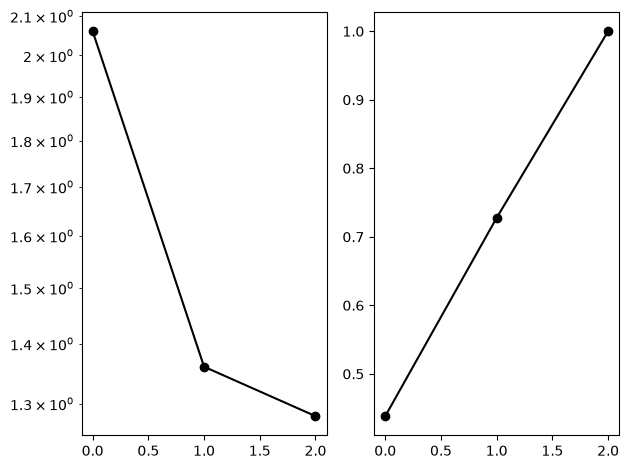

In [12]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(121)
ax1.semilogy(eigenvalues,'-o',color='k')
ax2 = fig1.add_subplot(122)
ax2.plot(np.cumsum(eigenvalues)/np.sum(eigenvalues),'-o',color='k')

plt.tight_layout()
plt.show()

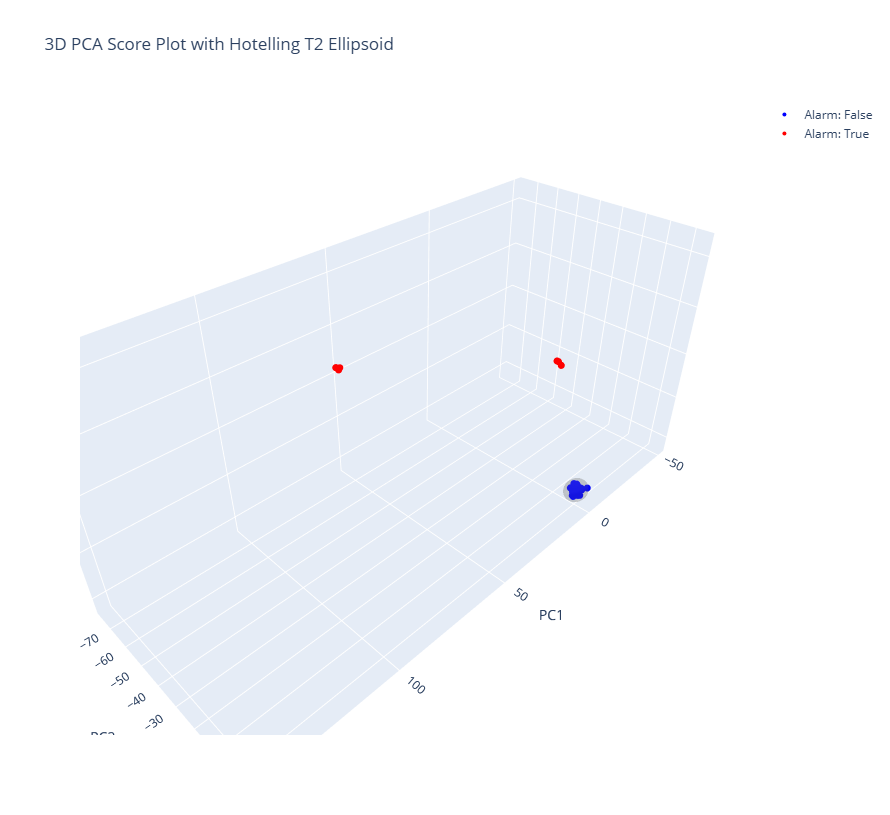

In [32]:
# Representing the PCA space and batches within this space

df_plot = pd.DataFrame(scores, columns=["PC1", "PC2", "PC3"])
df_plot['Alarm'] = df_pca_final['Alarm'].values
df_plot['Status'] = df_pca_final['Status'].values

eigenvalues = pca_golden.explained_variance_
radius_x = np.sqrt(t2_threshold * eigenvalues[0])
radius_y = np.sqrt(t2_threshold * eigenvalues[1])
radius_z = np.sqrt(t2_threshold * eigenvalues[2])

# 3. Create the Ellipse Shape
phi = np.linspace(0, np.pi, 50)
theta = np.linspace(0, 2 * np.pi, 50)
phi, theta = np.meshgrid(phi, theta)

x_ellipse = radius_x * np.sin(phi) * np.cos(theta)
y_ellipse = radius_y * np.sin(phi) * np.sin(theta)
z_ellipse = radius_z * np.cos(phi)


fig = go.Figure()

for alarm_val, color in zip([False, True], ['blue', 'red']):
    mask = df_plot['Alarm'] == alarm_val
    fig.add_trace(go.Scatter3d(
        x=df_plot.loc[mask, 'PC1'],
        y=df_plot.loc[mask, 'PC2'],
        z=df_plot.loc[mask, 'PC3'],
        mode='markers',
        marker=dict(size=4, color=color),
        name=f'Alarm: {alarm_val}'
    ))

fig.add_trace(go.Surface(
    x=x_ellipse, y=y_ellipse, z=z_ellipse,
    opacity=0.2,
    showscale=False,
    colorscale=[[0, 'gray'], [1, 'gray']],
    name='95% T2 Ellipsoid'
))

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title="3D PCA Score Plot with Hotelling T2 Ellipsoid"
)

fig.update_layout(
    width=1200,
    height=800,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
)
fig.show()

In [14]:
# Reconstruct the data from the PCA space
# This tries to 'guess' what the original values were based on the PCs
reconstructed = pca_golden.inverse_transform(scores)

# Calculate the difference between actual scaled data and reconstruction
residuals = all_scaled - reconstructed
spe_values = np.sum(residuals**2, axis=1)

# Calculate SPE threshold (Simplified Jackson-Mudholkar approximation)
# using the mean and variance of golden residuals:
spe_golden = spe_values[golden_mask]
mean_spe = np.mean(spe_golden)
var_spe = np.var(spe_golden)
g = var_spe / (2 * mean_spe)
h = (2 * mean_spe**2) / var_spe
spe_threshold = g * stats.chi2.ppf(1 - alpha, h)

df_pca_final['SPE_Statistic'] = spe_values
df_pca_final['SPE_Threshold'] = spe_threshold

In [15]:
spe_values

array([1.66813923e+03, 8.01942235e-01, 2.26919537e+00, 4.56130756e-01,
       4.91239428e+00, 8.38807611e+03, 8.56797626e+03, 2.37013564e+00,
       6.06220878e+03, 8.18525654e+03, 1.57632724e+00, 3.43548430e-01,
       1.57575068e+03, 1.03010701e+00, 2.65633768e+00, 2.60331610e+00,
       1.59153888e+03, 5.66971364e-01, 1.93257552e+00, 5.57828599e-01,
       5.99875818e+03, 1.73344083e+03, 1.11902135e-01, 9.73321777e-01,
       1.69190634e-01, 4.38585887e-01, 5.80129109e+03, 3.00199615e+00,
       3.59887360e+00, 2.18157951e-01, 1.10688284e+00, 1.51101381e+03,
       6.80100073e-01, 4.64996358e-01, 2.16220653e+00, 2.43604153e-01,
       3.52454944e-01, 1.01600030e+00, 1.12556477e-01, 2.90828997e+00,
       4.04049032e+00, 1.54206104e+03, 1.05145532e+00, 8.83436114e-01,
       1.77170206e+00, 1.61901392e+03, 5.78895566e+03, 7.88761248e-01,
       1.54207378e+03, 1.97639471e+00])

In [16]:
h_spe_mask = df_pca_final["SPE_Statistic"] > spe_threshold 
OOS_mask = df_pca_final["Status"] != "Golden"
alarm_mask = df_pca_final["Alarm"] == True
l_spe_mask = df_pca_final["SPE_Statistic"] < spe_threshold
h_t2_mask = df_pca_final["T2_Statistic"] > 14.214428
df_pca_final[l_spe_mask & h_t2_mask]

,Batch_ID,Status,Full_Titer,Max_Ammonia,Max_Lactate,Min_pH,Avg_Growth_Rate,Avg_Prod_Rate,Avg_Gluc_Cons,T2_Statistic,OOS_Threshold,Alarm,SPE_Statistic,SPE_Threshold


In [17]:
df_pca_final.head()

,Batch_ID,Status,Full_Titer,Max_Ammonia,Max_Lactate,Min_pH,Avg_Growth_Rate,Avg_Prod_Rate,Avg_Gluc_Cons,T2_Statistic,OOS_Threshold,Alarm,SPE_Statistic,SPE_Threshold
0,BATCH_010,OOS_Toxic_Drift,1.561249,5.101116,9.203172,6.776570,0.015049,0.002331,-0.042223,20033.169636,14.214428,True,1668.139234,5.585588
1,BATCH_013,Golden,2.579343,5.183915,30.939462,5.706865,0.014952,0.002327,-0.030233,4.825387,14.214428,False,0.801942,5.585588
2,BATCH_018,Golden,2.320695,5.106228,30.775563,5.705915,0.015134,0.002381,-0.035729,0.698151,14.214428,False,2.269195,5.585588
3,BATCH_021,Golden,2.401969,5.117871,31.209851,5.680879,0.015156,0.002255,-0.037484,12.138691,14.214428,False,0.456131,5.585588
4,BATCH_027,Golden,2.367965,5.079535,30.910155,5.706604,0.014789,0.002359,-0.037229,2.084584,14.214428,False,4.912394,5.585588


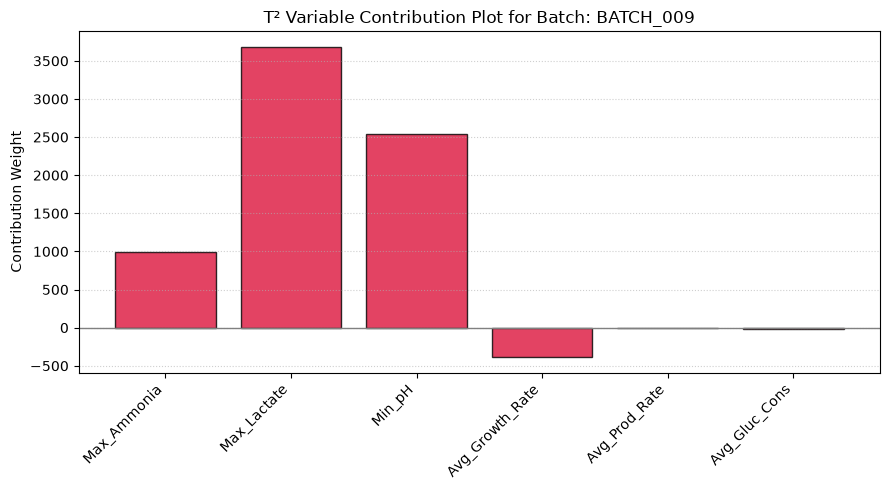

In [18]:
def plot_t2_contribution(df, batch_id, id_col, feature_cols, all_scaled, scores, pca_model):
    batch_idx = df[df[id_col] == batch_id].index[0]
    
    failed_batch_scaled = all_scaled[batch_idx] 
    contributions = np.zeros(len(feature_cols))

    for i in range(len(feature_cols)):
        contribution_i = 0
        for pc_idx in range(pca_model.n_components_):
            loading = pca_model.components_[pc_idx, i]
            score = scores[batch_idx, pc_idx]
            eigenvalue = pca_model.explained_variance_[pc_idx]
            contribution_i += score * loading / eigenvalue
        
        contributions[i] = failed_batch_scaled[i] * contribution_i

    plt.figure(figsize=(9, 5))
    plt.bar(feature_cols, contributions, color='crimson', edgecolor='black', alpha=0.8)
    plt.axhline(0, color='grey', lw=1)
    plt.title(f'T² Variable Contribution Plot for Batch: {batch_id}')
    plt.ylabel('Contribution Weight')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_t2_contribution(
    df=df_pca_final, 
    batch_id="BATCH_009", 
    id_col="Batch_ID", 
    feature_cols= feature_cols, 
    all_scaled=all_scaled, 
    scores=scores, 
    pca_model=pca_golden
)

## Hierarchical clustering

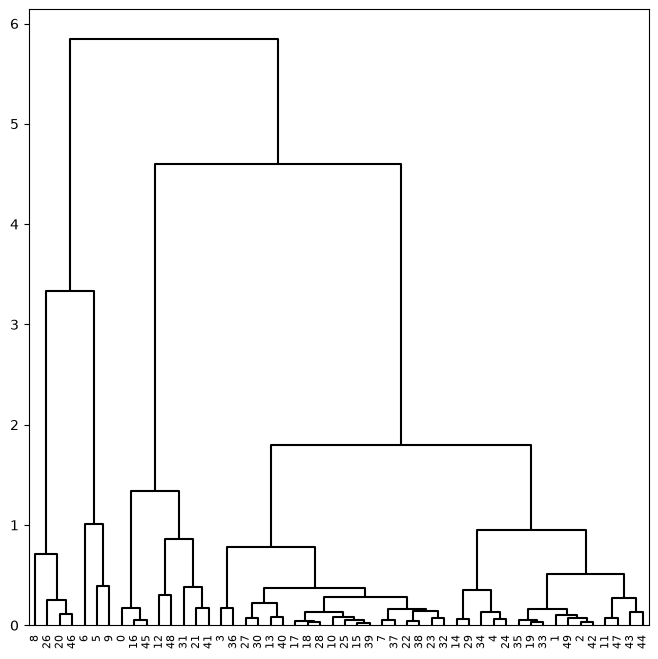

In [19]:
X = df_pca_plot[['PC1', 'PC2']].values
# 'complete' linkage matches your previous code
Z = linkage(X, method='complete')

# 3. Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# mimic your cargs: color_threshold=-np.inf makes the whole tree one color
dendrogram(
    Z, 
    ax=ax, 
    color_threshold=-np.inf, 
    above_threshold_color='black'
)

plt.show()

## K-means cluster

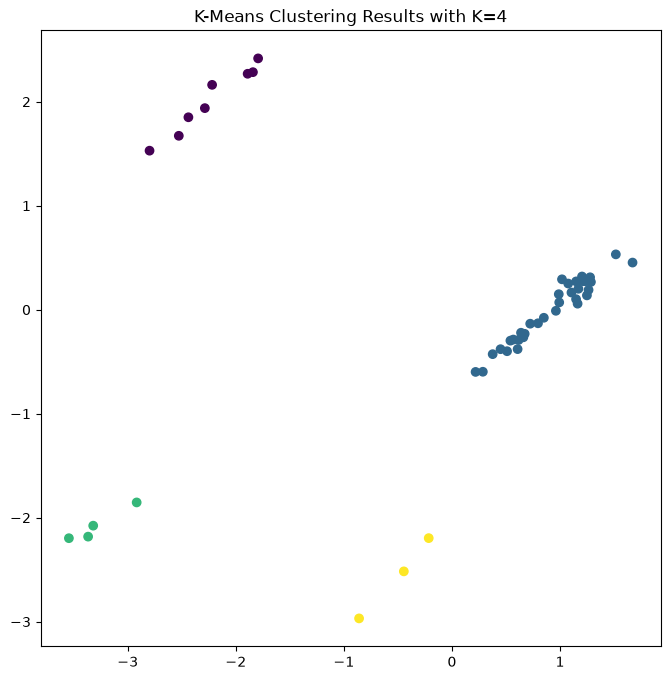

In [20]:
X = df_pca_plot[['PC1', 'PC2']].values
kmeans = KMeans(n_clusters=4, random_state=2, n_init=20).fit(X)

fig , ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=4");

# Checkpoint Prediction Engine

In [21]:
query = """
SELECT *
FROM telemetry_aligned 
WHERE Hour <= 140
"""

telemetry_random_forest = con.execute(query).df()

query_2 = """
SELECT 
    o.Batch_ID, 
    o.Full_Titer, 
FROM outcomes o
"""
outcome_random_forest = con.execute(query_2).df()

In [22]:
telemetry_random_forest.head()

,Batch_ID,Hour,VCD,Glucose,Lactate,Ammonia,Product,pH,dt,Growth_Rate,Production_Rate,Consumption_Rate
0,BATCH_000,0.0,0.500817,51.167296,0.000000,0.000000,0.0,7.190487,NaN,NaN,NaN,NaN
1,BATCH_000,1.0,0.521538,51.060926,0.041431,0.006823,0.0,7.194654,1.0,0.039729,0.0,-0.203956
2,BATCH_000,2.0,0.562978,50.848184,0.078675,0.013051,0.0,7.199229,1.0,0.073610,0.0,-0.377886
3,BATCH_000,3.0,0.583698,50.741813,0.095203,0.015867,0.0,7.201719,1.0,0.035498,0.0,-0.182236
4,BATCH_000,4.0,0.604419,50.635443,0.111730,0.018684,0.0,7.204210,1.0,0.034281,0.0,-0.175989


In [23]:
def preparing_features(df_tel, df_out, checkpoint_hour):
    df_tel = df_tel.sort_values(by=['Batch_ID', 'Hour']).reset_index(drop=True)
    processed_features = []
    process_variables = ['VCD', 'Glucose', 'Lactate', 'Ammonia', 'Product', 'pH', 'Growth_Rate', 'Production_Rate', 'Consumption_Rate']
    
    for batch_id, batch_group in df_tel.groupby('Batch_ID'):
        # Limit data to given checkpoint hour (function argument) and put in chronological order
        group_to_hour = batch_group[batch_group['Hour'] <= checkpoint_hour].sort_values('Hour')
            
        # Creates a dataframe populated with the current batch_id of the loop
        batch_features = pd.DataFrame({'Batch_ID': [batch_id]})

        # Locate the checkpoint row
        matched_row = group_to_hour[group_to_hour['Hour'] == checkpoint_hour]

        # Extract the state and find its relative integer position in the group
        if not matched_row.empty:
            label = matched_row.index[0]
            checkpoint_index = group_to_hour.index.get_loc(label)

        # Calculating and/or storing current value, lag1 and 2, rolling average and standard deviation
        # cumulative sum
        for col in process_variables:
            batch_features[f'{col}_current'] = group_to_hour[col].iloc[checkpoint_index]
            
            batch_features[f'{col}_lag1'] = group_to_hour[col].iloc[checkpoint_index - 1]
            batch_features[f'{col}_lag2'] = group_to_hour[col].iloc[checkpoint_index - 2]
            
            short_window = group_to_hour[col].iloc[(checkpoint_index - 2):(checkpoint_index + 1)]
            batch_features[f'{col}_roll_mean3'] = short_window.mean()
            batch_features[f'{col}_roll_std3'] = short_window.std()
            
            if checkpoint_index >= 11:
                macro_window = group_to_hour.iloc[(checkpoint_index - 11):(checkpoint_index + 1)]
                hourly_rates = macro_window[col].diff().dropna() / macro_window['Hour'].diff().dropna()
                batch_features[f'{col}_avg_rate_12h'] = hourly_rates.mean()
            else:
                batch_features[f'{col}_avg_rate_12h'] = np.nan
                
            y = group_to_hour[col].values
            x = group_to_hour['Hour'].values
            if len(x) > 1:
                batch_features[f'{col}_cum_area'] = trapezoid(y, x)
            else:
                batch_features[f'{col}_cum_area'] = 0.0
                
        processed_features.append(batch_features)
              
    df_features_matrix = pd.concat(processed_features, ignore_index=True)
    df_modeling_set = pd.merge(df_features_matrix, df_out[['Batch_ID', 'Full_Titer']], on='Batch_ID', how='inner')

    
    return df_modeling_set

In [24]:
df_cp_75 = preparing_features(telemetry_random_forest,outcome_random_forest,75)
df_cp_100 = preparing_features(telemetry_random_forest,outcome_random_forest,100)

In [25]:
df_cp_75.head()

,Batch_ID,VCD_current,VCD_lag1,VCD_lag2,VCD_roll_mean3,VCD_roll_std3,VCD_avg_rate_12h,VCD_cum_area,Glucose_current,Glucose_lag1,...,Production_Rate_avg_rate_12h,Production_Rate_cum_area,Consumption_Rate_current,Consumption_Rate_lag1,Consumption_Rate_lag2,Consumption_Rate_roll_mean3,Consumption_Rate_roll_std3,Consumption_Rate_avg_rate_12h,Consumption_Rate_cum_area,Full_Titer
0,BATCH_000,7.362007,7.218465,6.931382,7.170618,0.219263,0.172120,210.418401,33.122978,33.500705,...,0.000177,NaN,-0.051308,-0.104656,-0.054495,-0.070153,0.029923,0.002281,NaN,2.607522
1,BATCH_001,7.227769,6.921413,6.768234,6.972472,0.233984,0.178950,205.769842,33.603693,34.385671,...,0.000376,NaN,-0.108191,-0.056490,-0.119634,-0.094772,0.033643,-0.006217,NaN,2.275756
2,BATCH_002,7.077603,6.932021,6.640856,6.883493,0.222381,0.170716,204.688232,13.448520,13.819620,...,0.000192,NaN,-0.052433,-0.107068,-0.092246,-0.083916,0.028254,-0.000545,NaN,1.661988
3,BATCH_003,7.187819,6.900907,6.757452,6.948726,0.219132,0.171197,205.283723,12.819203,13.480594,...,0.000352,NaN,-0.092016,-0.047921,-0.097876,-0.079271,0.027308,0.000878,NaN,1.666431
4,BATCH_004,7.273261,6.947273,6.784278,7.001604,0.248978,0.168101,210.655389,33.099815,33.898792,...,0.000399,NaN,-0.109851,-0.057503,-0.123131,-0.096828,0.034698,-0.002681,NaN,2.592127


In [26]:
def training_random_forest_1(df, tree_number):
    # Arguments: df is a dataframe containing the variables for a given checkpoint time of the culture
    # tree_number is the number of tree build in the ensemble method 
    
    # Defining response, explanatory variables and splitting for training and testing
    y = df["Full_Titer"]
    X = df.drop(columns=["Full_Titer", "Batch_ID"]).copy()
    (X_train , X_test , y_train , y_test) = skm.train_test_split(X, y , test_size=0.3,random_state=0)

    # Building the Random forest regression model with training data
    m_features = int(np.round(np.sqrt(X_train.shape[1])))
    all_features = int(np.round(X_train.shape[1]))
    checkpoint_model = RFR(max_features= m_features, n_estimators=tree_number, oob_score=True, random_state=0)
    checkpoint_model.fit(X_train , y_train)
    
    # Calculating prediction error based on test data
    y_hat_bag = checkpoint_model.predict(X_test)
    rmse_test = np.sqrt(np.mean((y_test - y_hat_bag)**2))
    slope, intercept, r, p, std_err = stats.linregress(y_test, y_hat_bag)
    
    feature_imp = pd.DataFrame(
                {'importance':checkpoint_model.feature_importances_},
                index=X.columns)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    
    # Plotting and calculation for evaluation of the model
    fig , (ax_1, ax_2) = plt.subplots(2, 1, figsize=(16,8))
    ax_1.scatter(y_hat_bag , y_test)
    ax_2.bar(feature_imp.index, feature_imp["importance"])
    ax_2.set_xticklabels(feature_imp.index, rotation=45, ha='right')

    print(f"RMSE:  {rmse_test}, R^2: {r*r}, OOB score:  {checkpoint_model.oob_score_}")
    print(feature_imp)
    
    return checkpoint_model

In [27]:
def training_random_forest_3(df):
    # Arguments: df is a dataframe containing the variables for a given checkpoint time of the culture
    # This version uses cross validation for hyperparameters tuning
    
    # Defining response, explanatory variables and splitting for training and testing
    y = df["Full_Titer"]
    X = df.drop(columns=["Full_Titer", "Batch_ID"]).copy()
    (X_train , X_test , y_train , y_test) = skm.train_test_split(X, y , test_size=0.3,random_state=0)

    # Building the Random forest regression model with training data
    m_features = int(np.round(np.sqrt(X_train.shape[1])))
    all_features = int(np.round(X_train.shape[1]))

    grid_parameters = {"n_estimators" : range(100,600,100), 
                        "max_depth" : range(5,30,5), 
                        "min_samples_leaf": range(1,11,1), 
                        "max_features" : range(m_features,all_features+1,5)
                      }
    # making n_iter combination of grid_parameters values and test it for best model using scoring
    # this is repeated with cv number of segmentation of the given data (see fit)
    random_search = skm.RandomizedSearchCV(RFR(random_state=0),
                                         param_distributions= grid_parameters,
                                         n_iter=5,
                                         scoring= "neg_root_mean_squared_error",
                                         cv= 5
                                        )
    
    random_search.fit(X_train , y_train)

    train_score = -random_search.score(X_train, y_train)
    test_score = -random_search.score(X_test, y_test)

    best_rf = random_search.best_estimator_
    kf = skm.KFold(n_splits=5, shuffle=True, random_state=42)
    scores = -skm.cross_val_score(best_rf, X_test, y_test, cv=kf, scoring='neg_root_mean_squared_error')
    rmse_std = np.std(scores)
    
    # Calculating prediction error based on test data
    y_hat_bag = best_rf.predict(X_test)
    slope, intercept, r, p, std_err = stats.linregress(y_test, y_hat_bag)

    # Comparison between feature importance from RFR and Shap values
    explainer = shap.Explainer(best_rf)
    shap_values = explainer(X_test)
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    shap_importance = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False)
    
    shap_df = pd.DataFrame({"shap values":shap_importance}, index=X.columns) 
    
    feature_imp = pd.DataFrame(
                {'feature importance':best_rf.feature_importances_},
                index=X.columns)
    feature_imp = feature_imp.sort_values(by='feature importance', ascending=False)

    shap_vs_imp = pd.merge(feature_imp, shap_df, left_index=True, right_index=True)
    scaler = MinMaxScaler()
    shap_vs_imp_norm = pd.DataFrame(scaler.fit_transform(shap_vs_imp),
                                    columns=shap_vs_imp.columns,
                                    index=shap_vs_imp.index
                                    ).sort_values(by='shap values', ascending=False)

    print(f"RMSE test score: {test_score}, CV test RMSE mean: {np.mean(scores)}, CV test RMSE std: {rmse_std},R^2: {r*r}")
    
    # Plotting for model evaluation
    fig = make_subplots(rows=2, cols=2,
                        specs=[
                              [{}, {}],                # Row 1: Two independent plots
                              [{"colspan": 2}, None]   # Row 2: One plot spanning 2 cols
                              ],
                        subplot_titles=("Predicted vs actual full titer", 
                        "Shap value vs importance from RFR (both standardized)", 
                        "Random Forest Regression feature importance")
                       )
    
    fig.add_trace(go.Scatter(x=y_hat_bag , y=y_test, mode='markers'), row=1, col=1)
    fig.add_trace(go.Scatter(x=shap_vs_imp_norm["shap values"], y=shap_vs_imp_norm["feature importance"], mode='markers'), row=1, col=2)
    fig.add_trace(go.Bar(x=feature_imp.index[0:16], y=feature_imp["feature importance"].iloc[0:16]), row=2, col= 1)
   
    fig.update_xaxes(title_text="Predicted Titer", row=1, col=1)
    fig.update_yaxes(title_text="Actual Titer", row=1, col=1)

    fig.update_xaxes(title_text="Standardized SHAP Value", row=1, col=2)
    fig.update_yaxes(title_text="Standardized Importance", row=1, col=2)

    fig.update_xaxes(title_text="Features", tickangle=45, row=2, col=1)
    fig.update_yaxes(title_text="Importance Value", row=2, col=1)
    fig.update_xaxes(tickangle=45, row=2, col=1)
    
    fig.update_layout(
        height=600, 
        width=1000, 
        title_text="Random Forest Regression for the given data",
        showlegend=False
                    )
    fig.show()

    shap.plots.beeswarm(shap_values)
    
    return best_rf

RMSE test score: 0.11798814917848624, CV test RMSE mean: 0.20529022906443045, CV test RMSE std: 0.09800718614348422,R^2: 0.9362046233005042


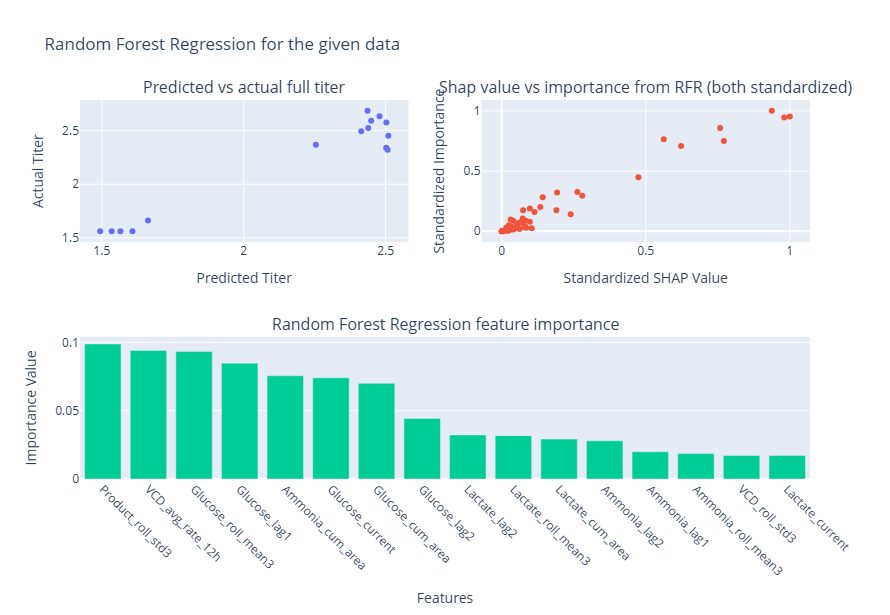

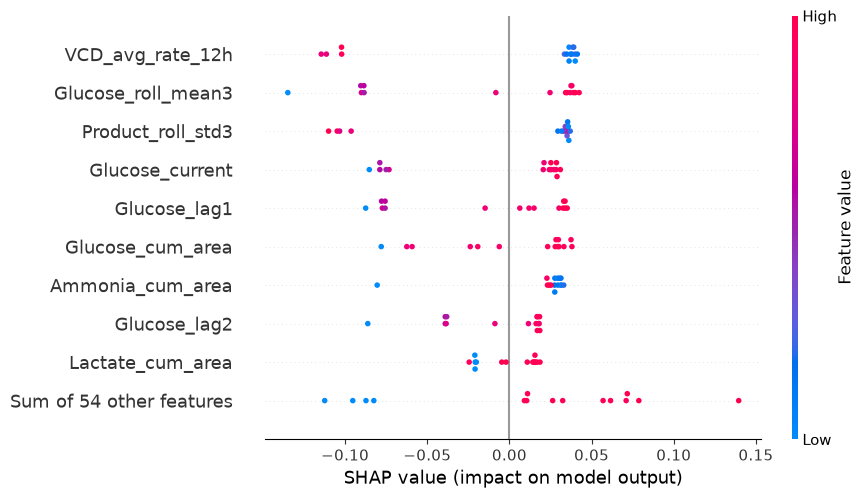

In [28]:
cp_75_model = training_random_forest_3(df_cp_75)

RMSE test score: 0.12613503955397365, CV test RMSE mean: 0.18686806321278104, CV test RMSE std: 0.07341519962247728,R^2: 0.9299194817697021


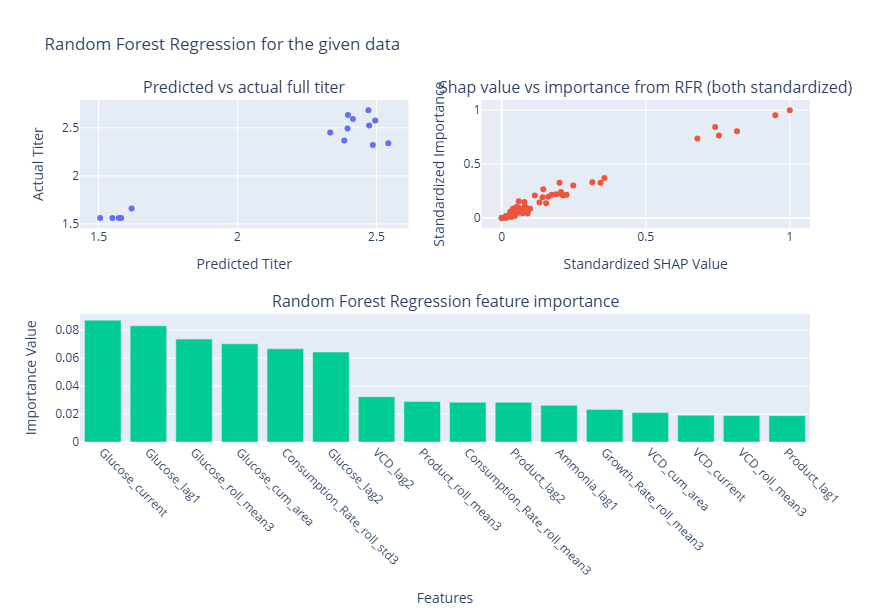

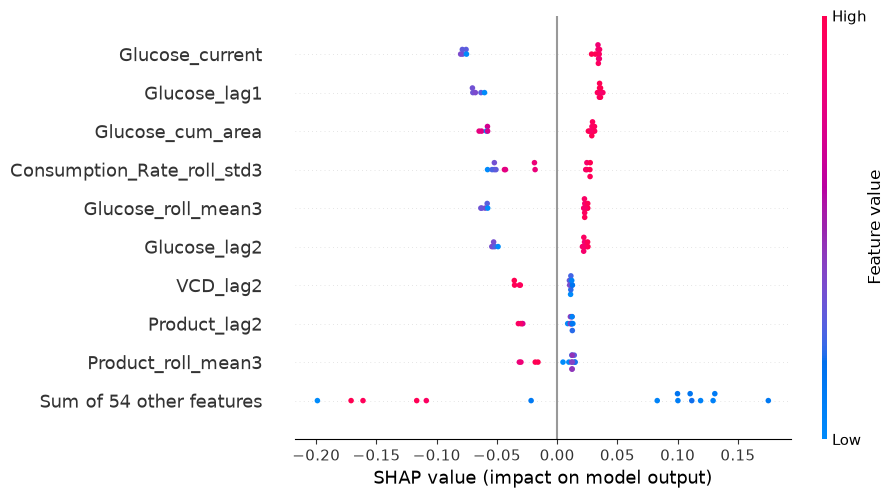

In [29]:
cp_100_model = training_random_forest_3(df_cp_100)

In [30]:
# To be reused only to change existing model
# joblib.dump(cp_75_model , "C:\dev\AAV_Process_Modeling\models\Classifier_75h_model.joblib")
# joblib.dump(cp_100_model , "C:\dev\AAV_Process_Modeling\models\Classifier_100h_model.joblib")